# 505: Cross-Decade and Cross-Quantile Contribution Comparisons

Sorts the decomposition analysis by two different criteria: decade in which NZCO2
is reached (per scenario), and quantile of GSAT in 2100. Shows the median values
in both cases: median-of-medians for the decade comparison; median across scenarios 
of one real selected member per quantile level for the quantile comparison

Output:
- `505_SFigure_5.png`
- `505_Figure_4.png`
- `505_p50_ongoing_warming_decomposition.png`

In [1]:
import os
from pathlib import Path

import dotenv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

dotenv.load_dotenv()

OUTPUT_FOLDER = Path(os.environ["OUTPUT_FOLDER"])
PLOT_FOLDER = OUTPUT_FOLDER / "plots"
PLOT_FOLDER.mkdir(parents=True, exist_ok=True)

MANIFEST_ID = "regenerated"
METRICS_FILE = OUTPUT_FOLDER / f"500b_component_metrics_extended_{MANIFEST_ID}.csv"

GROUPS = [
    "Scenarios (NZCO2)",
    "Scenarios (NZGHG)",
    "Stylised Variants (NZCO2-hold)",
    "Stylised Variants (NZGHG-hold)",
]

COMPONENTS = ["ANTHROPOGENIC", "CO2_NZCO2", "CO2_Negative", "NonCO2_GHG", "Residual"]
DELTA_COMPONENTS = ["CO2_NZCO2", "CO2_Negative", "NonCO2_GHG", "Residual"]

In [2]:
metrics_df = pd.read_csv(METRICS_FILE, index_col=0)

## Bucket Scenarios by Net-Zero-CO2 Timing

In [3]:
# Decade-aligned buckets, with the sparse 2030s folded into the 2040s and the single
# year 2090 folded into the 2080s.
BUCKET_ORDER = ["≤2049", "2050s", "2060s", "2070s", "≥2080"]
BUCKET_BIN_EDGES = [2029, 2049, 2059, 2069, 2079, 2090]

metrics_df["netzero_bucket"] = pd.cut(
    metrics_df["year_netzero_co2"],
    bins=BUCKET_BIN_EDGES,
    labels=BUCKET_ORDER,
    include_lowest=True,
)

## Per-Scenario Medians and Median-of-Medians Group Statistics

In [4]:
def calc_scenario_medians(df, groups):
    """Per-scenario MEDIAN (across ensemble members) of the endpoint GSAT levels -
    used for the start (NZCO2) and end (2100) bars."""
    value_cols = [c for c in df.columns if c.startswith("GSAT|")]
    scenario_medians = df.groupby(["model", "scenario", "scenario_group"])[value_cols].median()
    return {
        group: scenario_medians[scenario_medians.index.get_level_values("scenario_group") == group]
        for group in groups
    }


def calc_median_of_median_by_group(metrics_df, components, groups, extraction_mode="netzero_co2"):
    """For each delta component, compute per-scenario median (across members), then
    the median-of-medians across scenarios (the bar-height statistic), alongside
    percentile-of-percentile error bars (p05/p17/p83/p95), per scenario_group.

    NOT additive: median(A) + median(B) != median(A+B) in general, unlike the
    mean-of-means version this replaces - the stacked component bars below will not
    sum exactly to the NZCO2-to-2100 endpoint difference. Accepted tradeoff, same as
    503's original median-based waterfall.
    """
    delta_cols = [f"GSAT|{c}|delta_{extraction_mode}" for c in components if f"GSAT|{c}|delta_{extraction_mode}" in metrics_df.columns]
    quantiles = {"p05": 0.05, "p17": 0.17, "p83": 0.83, "p95": 0.95}

    scenario_stats = metrics_df.groupby(["model", "scenario", "scenario_group"])[delta_cols].agg(
        ["median"] + [lambda x, q=q: x.quantile(q) for q in quantiles.values()]
    )
    stat_names = ["median"] + list(quantiles.keys())
    scenario_stats.columns = [f"{col}|{name}" for col in delta_cols for name in stat_names]

    results = {}
    for group in groups:
        gdf = scenario_stats[scenario_stats.index.get_level_values("scenario_group") == group]
        rows = {}
        for comp in components:
            col_base = f"GSAT|{comp}|delta_{extraction_mode}"
            if f"{col_base}|median" not in gdf.columns:
                continue
            rows[comp] = {
                "median_of_median": gdf[f"{col_base}|median"].median(),
                "p05_of_p05": gdf[f"{col_base}|p05"].quantile(0.05),
                "p17_of_p17": gdf[f"{col_base}|p17"].quantile(0.17),
                "p83_of_p83": gdf[f"{col_base}|p83"].quantile(0.83),
                "p95_of_p95": gdf[f"{col_base}|p95"].quantile(0.95),
            }
        if rows:
            df = pd.DataFrame(rows).T
            df.index.name = "Component"
            results[group] = df
    return results

## Cross-Decade Comparison

The waterfalls above make each bucket's own internal decomposition easy to read, but
hard to compare *across* buckets at a glance (five separate figures). This summarizes
the same underlying numbers - for `Scenarios (NZCO2)` - in one figure with two panels,
one bar group per bucket:

- **Panel a)**: median GSAT at the net-zero-CO2 year and at 2100, side by side per
  bucket - the absolute start/end levels.
- **Panel b)**: the four delta components (`ZEC*`, `CO2 Neg`, `Non-CO2 GHG`, `Residual`)
  stacked per bucket - the decomposition of the NZCO2-to-2100 change itself - plus a
  dashed "Net change" marker: a pure visual aid showing the sum of the four stacked
  components (not derived from panel a)'s endpoint difference), since diverging
  (positive-up/negative-down) stacking otherwise makes it hard to see at a glance
  where the actual net total lands once positive and negative segments partly cancel.

No error bars here (stacking obscures per-segment uncertainty ranges) - see the
waterfall figures above for the full percentile-of-percentile ranges per bucket.


In [5]:
comparison_rows = []
for group in GROUPS:
    for bucket in BUCKET_ORDER:
        bucket_df = metrics_df[
            (metrics_df["netzero_bucket"] == bucket)
            & (metrics_df["scenario_group"] == group)
        ]
        if bucket_df.empty:
            continue

        scenario_medians = calc_scenario_medians(bucket_df, [group])[group]
        pop_stats = calc_median_of_median_by_group(bucket_df, DELTA_COMPONENTS, [group], "netzero_co2")[group]

        row = {
            "scenario_group": group,
            "bucket": bucket,
            "n": len(scenario_medians),
            "nzco2_median": scenario_medians["GSAT|ANTHROPOGENIC|netzero_co2"].median(),
            "y2100_median": scenario_medians["GSAT|ANTHROPOGENIC|2100"].median(),
        }
        for comp in DELTA_COMPONENTS:
            row[comp] = pop_stats.loc[comp, "median_of_median"] if comp in pop_stats.index else np.nan
        # Net change: a pure visual aid, literally the sum of the four component
        # values above (not derived from nzco2_median/y2100_median) - see markdown.
        row["net_change"] = sum(row[comp] for comp in DELTA_COMPONENTS)
        comparison_rows.append(row)

comparison_df = pd.DataFrame(comparison_rows).set_index(["scenario_group", "bucket"])
comparison_df


n  nzco2_median  y2100_median  \
scenario_group                 bucket                                    
Scenarios (NZCO2)              ≤2049    50      1.627966      1.333785   
                               2050s   144      1.677921      1.451827   
                               2060s   202      1.805569      1.628741   
                               2070s   176      1.887902      1.789345   
                               ≥2080   212      1.858097      1.850996   
Scenarios (NZGHG)              ≤2049    28      1.637901      1.269091   
                               2050s    93      1.678427      1.378141   
                               2060s   138      1.830859      1.620558   
                               2070s    97      1.912680      1.785810   
                               ≥2080    31      2.126744      2.069793   
Stylised Variants (NZCO2-hold) ≤2049    50      1.627966      1.520924   
                               2050s   144      1.677921      1.595248   
                               2060s   202      1.805569      1.750307   
                               2070s   176      1.887902      1.849119   
                               ≥2080   212      1.858097      1.852158   
Stylised Variants (NZGHG-hold) ≤2049    28      1.637901      1.370039   
                               2050s    93      1.678427      1.457901   
                               2060s   138      1.830859      1.677161   
                               2070s    97      1.912680      1.801823   
                               ≥2080    31      2.126744      2.075437   

                                       CO2_NZCO2  CO2_Negative  NonCO2_GHG  \
scenario_group                 bucket                                        
Scenarios (NZCO2)              ≤2049   -0.053909     -0.188239   -0.022020   
                               2050s   -0.046705     -0.144036   -0.033895   
                               2060s   -0.034030     -0.105495   -0.028713   
                               2070s   -0.023670     -0.054444   -0.017995   
                               ≥2080   -0.012803     -0.000407   -0.002229   
Scenarios (NZGHG)              ≤2049   -0.058204     -0.222298   -0.042108   
                               2050s   -0.048711     -0.186357   -0.064333   
                               2060s   -0.033773     -0.127094   -0.043486   
                               2070s   -0.024594     -0.076751   -0.031242   
                               ≥2080   -0.014710     -0.033129   -0.023947   
Stylised Variants (NZCO2-hold) ≤2049   -0.053909      0.000000   -0.018289   
                               2050s   -0.046705      0.000000   -0.032364   
                               2060s   -0.034030      0.000000   -0.027428   
                               2070s   -0.023670      0.000000   -0.017726   
                               ≥2080   -0.012803      0.000000   -0.002214   
Stylised Variants (NZGHG-hold) ≤2049   -0.058204     -0.189358   -0.020222   
                               2050s   -0.048711     -0.134087   -0.041015   
                               2060s   -0.033773     -0.095046   -0.030627   
                               2070s   -0.024594     -0.064135   -0.028686   
                               ≥2080   -0.014710     -0.033129   -0.022598   

                                       Residual  net_change  
scenario_group                 bucket                        
Scenarios (NZCO2)              ≤2049  -0.017467   -0.281636  
                               2050s  -0.013603   -0.238239  
                               2060s  -0.015883   -0.184121  
                               2070s   0.006482   -0.089627  
                               ≥2080   0.001967   -0.013472  
Scenarios (NZGHG)              ≤2049   0.025711   -0.296898  
                               2050s  -0.017117   -0.316518  
                               2060s  -0.011122   -0.215474  
                               2070s   0.011134   -0.121454  
             

## Cross-Decade Comparison - Decomposition Only, 2x2 by Scenario Group

Same `comparison_df` decomposition data as the cross-decade comparison above
(panel b) content only - no absolute-GSAT-levels panel), but laid out as a 2x2 grid
by scenario group, one panel each, akin to `503_waterfall_contributions.png`'s
layout convention - rather than one row per group with two panels each. Mirrors
`505_cross_quantile_decomposition.png`'s layout, with bucket on the x-axis
instead of quantile level.


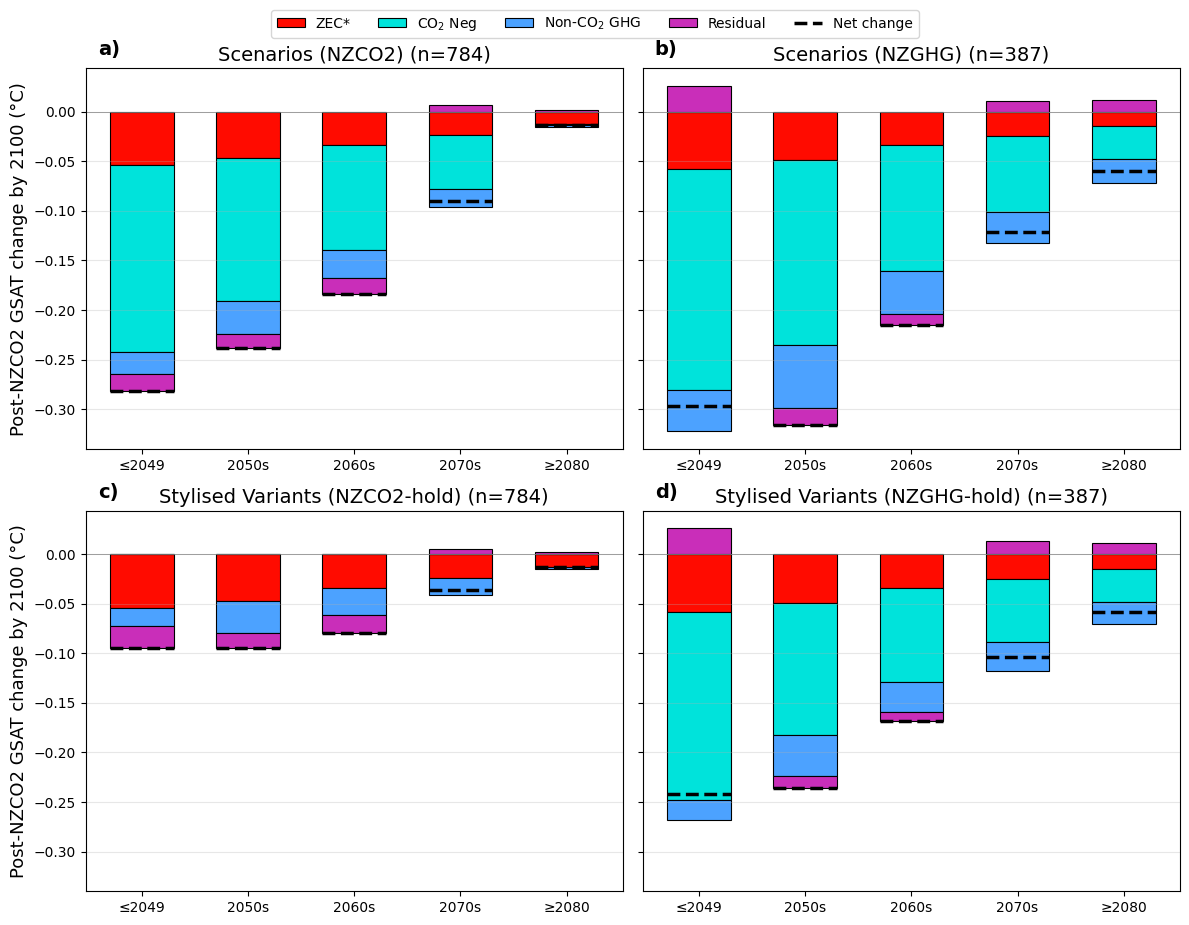

In [6]:
from matplotlib.lines import Line2D

color_delta = {
    'CO2_NZCO2': '#FF0B00',
    'CO2_Negative': '#00E3DB',
    'NonCO2_GHG': '#4CA2FF',
    'Residual': '#C92EB9',
}
component_labels = {
    'CO2_NZCO2': 'ZEC*',
    'CO2_Negative': 'CO$_2$ Neg',
    'NonCO2_GHG': 'Non-CO$_2$ GHG',
    'Residual': 'Residual',
}

x = np.arange(len(BUCKET_ORDER))

fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharey=True)
axes = axes.flatten()

for ax, group in zip(axes, GROUPS):
    gdf = comparison_df.loc[group].reindex(BUCKET_ORDER)

    pos_bottom = np.zeros(len(gdf))
    neg_bottom = np.zeros(len(gdf))
    for comp in DELTA_COMPONENTS:
        values = gdf[comp].values
        bottoms = np.where(values >= 0, pos_bottom, neg_bottom)
        ax.bar(x, values, width=0.6, bottom=bottoms, color=color_delta[comp],
               edgecolor="black", linewidth=0.8, label=component_labels[comp])
        pos_bottom = np.where(values >= 0, pos_bottom + values, pos_bottom)
        neg_bottom = np.where(values < 0, neg_bottom + values, neg_bottom)

    # Net change: a pure visual aid, literally the sum of the four stacked components
    # (comparison_df's "net_change" column) - see the cross-decade comparison
    # markdown above for why this isn't derived from an endpoint difference and
    # isn't guaranteed to match the stack exactly (median isn't additive).
    net_change = gdf["net_change"].values
    half_width = 0.3
    for i, net in enumerate(net_change):
        ax.plot([i - half_width, i + half_width], [net, net],
                color="black", linestyle="--", linewidth=2.5, zorder=5)

    # Each bucket has a different n (buckets partition the group's scenarios), unlike
    # the quantile version where n is the same at every quantile level - so the title
    # shows the group TOTAL (sum across buckets), not any single bucket's count.
    ax.set_xticks(x)
    ax.set_xticklabels(BUCKET_ORDER)
    ax.set_ylabel("Post-NZCO2 GSAT change by 2100 (°C)", fontsize=13)
    ax.set_title(f"{group} (n={int(gdf['n'].sum())})", fontsize=14)
    ax.grid(alpha=0.3, axis="y")
    ax.axhline(y=0, color="gray", linestyle="-", linewidth=0.5)

for ax in axes[1::2]:
    ax.set_ylabel("")

handles, labels = axes[0].get_legend_handles_labels()
net_change_handle = Line2D([0], [0], color="black", linestyle="--", linewidth=2.5, label="Net change")
fig.legend(handles + [net_change_handle], labels + ["Net change"], ncol=5, fontsize=10,
           loc="upper center", bbox_to_anchor=(0.5, 1.03))

plt.tight_layout()

labels_ab = ["a)", "b)", "c)", "d)"]
for ax, label in zip(axes, labels_ab):
    x_pos = ax.get_position().x0
    y_pos = ax.get_position().y1
    fig.text(x_pos + 0.01, y_pos + 0.01, label, fontsize=14, fontweight="bold", va="bottom")

plt.savefig(PLOT_FOLDER / "505_SFigure_5.png", dpi=150, bbox_inches="tight")
plt.show()

## Cross-Quantile Comparison

Same two-panel-per-group layout as the cross-decade comparison above, but each bar
group is now an ensemble **quantile level** (p05/p17/p50/p83/p95) instead of a
net-zero-timing bucket - i.e. resolving the single median-based waterfall decomposition
(503) across the climate-sensitivity ensemble, rather than collapsing it to one
central bar per component.

**Why one real member per scenario, not an independent quantile of each component
column:** stacking `CO2_NZCO2 + CO2_Negative + NonCO2_GHG + Residual` onto
`GSAT|ANTHROPOGENIC|netzero_co2` can only ever land exactly on
`GSAT|ANTHROPOGENIC|2100` for a single real member, where the per-member
decomposition identity (`ANTHRO = CO2_NZCO2 + CO2_Negative + NonCO2_GHG + Residual`)
holds exactly - independently taking `column.quantile(q)` for each component
separately can pick a *different* member for each column (the quantile of a sum is
not the sum of the quantiles in general - the same issue discussed for 503's
original delta-of-quantile bug, just arising here across components instead of
across time points). So for each scenario and each quantile level, this instead
selects one real member via nearest-rank, the same technique already used in
`502_overshoot_quantification.ipynb`'s ZEC$_{50}$-vs-peak-timing figure. This keeps
every selected member internally consistent (its own four components really do sum
to its own total) - it does **not**, however, make the figure's aggregate stack
additive: the MEDIAN across scenarios of each selected member's own values is taken
here (not mean), and median isn't additive, so the stacked bars below still won't sum
exactly to the NZCO2-to-2100 endpoint difference. The same dashed "Net change"
marker as the cross-decade comparison is shown here too - a pure visual aid, the sum
of the four stacked components, not derived from panel a)'s endpoint difference.

**Ranked by 2100 GSAT, not by the NZCO2-to-2100 delta itself:** ranking members by
their own `delta_netzero_co2` guarantees *that* quantity is monotonic across p05-p95
by construction, but the NZCO2-year absolute level (panel a)'s first bar) then comes
along unsorted and can be non-monotonic - verified empirically in an earlier version
of this figure (the p05 member's own NZCO2-year level sat *above* the p17 member's
level, in every scenario group). Ranking by 2100 GSAT instead keeps both panel a)
bars monotonic across quantile levels in every scenario group - checked explicitly
via assertion below, not just assumed. This ranking choice is independent of the
mean-vs-median question above: it determines *which member* gets selected at each
quantile level, not how the selected members are then combined across scenarios.


In [7]:
QUANTILE_LEVELS = {"p05": 0.05, "p17": 0.17, "p50": 0.50, "p83": 0.83, "p95": 0.95}
QUANTILE_ORDER = list(QUANTILE_LEVELS.keys())
RANK_COL = "GSAT|ANTHROPOGENIC|2100"


def pick_member_at_rank(group_df, q, rank_col=RANK_COL):
    """The real member nearest the q-th rank of `rank_col` (nearest-rank, not
    interpolated) - returns one actual ensemble member row, so every component read
    off it belongs to the same real member and the per-member decomposition identity
    holds exactly for that one member. Same technique as
    502_overshoot_quantification.ipynb's `pick_member_at_rank`. This only guarantees
    internal consistency per selected member - it does not by itself make the
    aggregate (across-scenario) stack additive, since scenarios are then combined via
    median, not mean (see markdown above).

    Ranked by 2100 GSAT rather than the NZCO2-to-2100 delta itself: ranking by the
    delta guarantees that quantity alone is monotonic across p05-p95, but the NZCO2-
    year absolute level (panel a) below) then comes along for the ride unsorted and
    can be non-monotonic (verified empirically - e.g. the p05 member's own NZCO2-year
    level sat above the p17 member's in every scenario group). Ranking by 2100 GSAT
    instead keeps both panel a) bars monotonic across quantile levels in every
    scenario group - checked empirically below, not just assumed."""
    sorted_df = group_df.sort_values(rank_col)
    idx = round(q * (len(sorted_df) - 1))
    return sorted_df.iloc[idx]


comparison_rows_quantile = []
for group in GROUPS:
    gdf_group = metrics_df[metrics_df["scenario_group"] == group]
    for label, q in QUANTILE_LEVELS.items():
        selected_members = pd.DataFrame(
            pick_member_at_rank(sdf, q) for _, sdf in gdf_group.groupby(["model", "scenario"])
        )
        row = {
            "scenario_group": group,
            "quantile_label": label,
            "n": len(selected_members),
            "nzco2_median": selected_members["GSAT|ANTHROPOGENIC|netzero_co2"].median(),
            "y2100_median": selected_members["GSAT|ANTHROPOGENIC|2100"].median(),
        }
        for comp in DELTA_COMPONENTS:
            row[comp] = selected_members[f"GSAT|{comp}|delta_netzero_co2"].median()
        # Net change: a pure visual aid, literally the sum of the four component
        # values above (not derived from nzco2_median/y2100_median) - see markdown.
        row["net_change"] = sum(row[comp] for comp in DELTA_COMPONENTS)
        comparison_rows_quantile.append(row)

comparison_df_quantile = pd.DataFrame(comparison_rows_quantile).set_index(["scenario_group", "quantile_label"])

# Additivity is NOT guaranteed here (median isn't additive, even with one real member
# selected per scenario) - report the gap between the stacked components' sum and the
# endpoint difference, rather than asserting they match.
gap = comparison_df_quantile["net_change"] - (comparison_df_quantile["y2100_median"] - comparison_df_quantile["nzco2_median"])
print(f"Stack-vs-endpoint gap (median non-additivity): max abs {gap.abs().max():.3f}, mean abs {gap.abs().mean():.3f} degC")

# Monotonicity check: both panel a) bars should still rise with quantile level in
# every scenario group - this only relies on each selected member's own 2100/NZCO2
# level being pointwise non-decreasing in q within a scenario, which doesn't depend
# on whether scenarios are then combined via mean or median.
for group in GROUPS:
    gdf_check = comparison_df_quantile.loc[group].reindex(QUANTILE_ORDER)
    for col in ["nzco2_median", "y2100_median"]:
        assert gdf_check[col].is_monotonic_increasing, f"{group}: {col} not monotonic across quantile levels"
print("PASS: NZCO2-year and 2100 GSAT levels are both monotonic across p05-p95 in every scenario group.")

Stack-vs-endpoint gap (median non-additivity): max abs 0.030, mean abs 0.013 degC
PASS: NZCO2-year and 2100 GSAT levels are both monotonic across p05-p95 in every scenario group.


## Cross-Quantile Comparison - Decomposition Only, 2x2 by Scenario Group

Same `comparison_df_quantile` decomposition data as the cross-quantile comparison
above (panel b) content only - no absolute-GSAT-levels panel), but laid out as a
2x2 grid by scenario group, one panel each, akin to
`503_waterfall_contributions.png`'s layout convention - rather than one row
per group with two panels each.


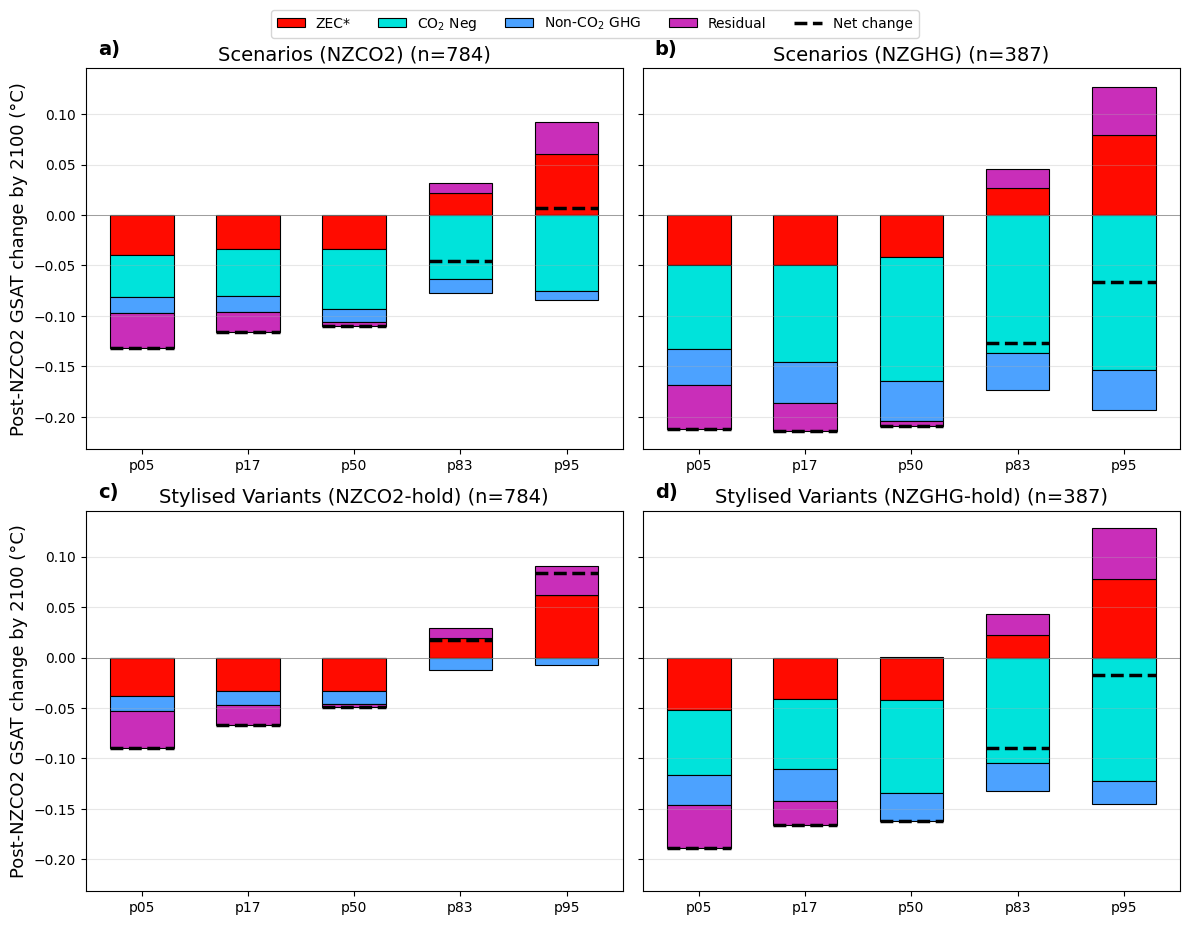

In [8]:
from matplotlib.lines import Line2D

color_delta = {
    'CO2_NZCO2': '#FF0B00',
    'CO2_Negative': '#00E3DB',
    'NonCO2_GHG': '#4CA2FF',
    'Residual': '#C92EB9',
}
component_labels = {
    'CO2_NZCO2': 'ZEC*',
    'CO2_Negative': 'CO$_2$ Neg',
    'NonCO2_GHG': 'Non-CO$_2$ GHG',
    'Residual': 'Residual',
}

x = np.arange(len(QUANTILE_ORDER))

fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharey=True)
axes = axes.flatten()

for ax, group in zip(axes, GROUPS):
    gdf = comparison_df_quantile.loc[group].reindex(QUANTILE_ORDER)

    pos_bottom = np.zeros(len(gdf))
    neg_bottom = np.zeros(len(gdf))
    for comp in DELTA_COMPONENTS:
        values = gdf[comp].values
        bottoms = np.where(values >= 0, pos_bottom, neg_bottom)
        ax.bar(x, values, width=0.6, bottom=bottoms, color=color_delta[comp],
               edgecolor="black", linewidth=0.8, label=component_labels[comp])
        pos_bottom = np.where(values >= 0, pos_bottom + values, pos_bottom)
        neg_bottom = np.where(values < 0, neg_bottom + values, neg_bottom)

    # Net change: a pure visual aid, literally the sum of the four stacked components
    # (comparison_df_quantile's "net_change" column) - see the cross-quantile
    # comparison markdown above for why this isn't derived from an endpoint
    # difference and isn't guaranteed to match the stack exactly (median isn't
    # additive).
    net_change = gdf["net_change"].values
    half_width = 0.3
    for i, net in enumerate(net_change):
        ax.plot([i - half_width, i + half_width], [net, net],
                color="black", linestyle="--", linewidth=2.5, zorder=5)

    ax.set_xticks(x)
    ax.set_xticklabels(QUANTILE_ORDER)
    ax.set_ylabel("Post-NZCO2 GSAT change by 2100 (°C)", fontsize=13)
    ax.set_title(f"{group} (n={int(gdf['n'].iloc[0])})", fontsize=14)
    ax.grid(alpha=0.3, axis="y")
    ax.axhline(y=0, color="gray", linestyle="-", linewidth=0.5)

for ax in axes[1::2]:
    ax.set_ylabel("")

handles, labels = axes[0].get_legend_handles_labels()
net_change_handle = Line2D([0], [0], color="black", linestyle="--", linewidth=2.5, label="Net change")
fig.legend(handles + [net_change_handle], labels + ["Net change"], ncol=5, fontsize=10,
           loc="upper center", bbox_to_anchor=(0.5, 1.03))

plt.tight_layout()

labels_ab = ["a)", "b)", "c)", "d)"]
for ax, label in zip(axes, labels_ab):
    x_pos = ax.get_position().x0
    y_pos = ax.get_position().y1
    fig.text(x_pos + 0.01, y_pos + 0.01, label, fontsize=14, fontweight="bold", va="bottom")

plt.savefig(PLOT_FOLDER / "505_Figure_4.png", dpi=150, bbox_inches="tight")
plt.show()

## p50 Ongoing-Warming Subset Decomposition

A targeted follow-up to the cross-quantile comparison above: restrict to the
scenarios whose own **p50 (median-rank) selected member** has `delta_netzero_co2 >
0` - i.e. "ongoing warming" at the median rather than "returns to/below GSAT(NZCO2)"
(the same criterion/terminology as `502_overshoot_quantification.ipynb`'s
`502_ZEC50_vs_peak_timing.png` marker split) - then decompose just that subset,
median across its scenarios, same member-selection and component logic as above.
One simple stacked bar per scenario group (no endpoint panel, no quantile-level
axis - this is a single slice at p50, filtered to one criterion subset). Sample
sizes are small for the two NZGHG-based groups (n=5 and n=11, since "ongoing
warming at p50" is rare once Kyoto-gas net-zero is reached) - shown via each bar's
own label, interpret those two with appropriate caution.


In [9]:
ongoing_warming_rows = []
for group in GROUPS:
    gdf_group = metrics_df[metrics_df["scenario_group"] == group]
    selected_p50 = pd.DataFrame(
        pick_member_at_rank(sdf, 0.5) for _, sdf in gdf_group.groupby(["model", "scenario"])
    )
    ongoing = selected_p50[selected_p50["GSAT|ANTHROPOGENIC|delta_netzero_co2"] > 0]

    row = {
        "scenario_group": group,
        "n": len(ongoing),
        "n_total": len(selected_p50),
        "nzco2_median": ongoing["GSAT|ANTHROPOGENIC|netzero_co2"].median(),
        "y2100_median": ongoing["GSAT|ANTHROPOGENIC|2100"].median(),
    }
    for comp in DELTA_COMPONENTS:
        row[comp] = ongoing[f"GSAT|{comp}|delta_netzero_co2"].median()
    row["net_change"] = sum(row[comp] for comp in DELTA_COMPONENTS)
    ongoing_warming_rows.append(row)

ongoing_warming_df = pd.DataFrame(ongoing_warming_rows).set_index("scenario_group")
print(ongoing_warming_df[["n", "n_total"]].assign(share=lambda d: d["n"] / d["n_total"]).round(3).to_string())
ongoing_warming_df

                                  n  n_total  share
scenario_group                                     
Scenarios (NZCO2)                79      784  0.101
Scenarios (NZGHG)                 5      387  0.013
Stylised Variants (NZCO2-hold)  158      784  0.202
Stylised Variants (NZGHG-hold)   11      387  0.028


,n,n_total,nzco2_median,y2100_median,CO2_NZCO2,CO2_Negative,NonCO2_GHG,Residual,net_change
scenario_group,,,,,,,,,
Scenarios (NZCO2),79,784,1.807494,1.817454,-0.008116,-0.000197,0.014938,0.016776,0.023401
Scenarios (NZGHG),5,387,1.561316,1.608611,-0.031632,-0.066304,-0.004510,0.128368,0.025922
Stylised Variants (NZCO2-hold),158,784,1.779818,1.801570,-0.015773,0.000000,0.008621,0.027219,0.020067
Stylised Variants (NZGHG-hold),11,387,1.793034,1.797920,-0.006576,-0.089811,-0.003919,0.102977,0.002671


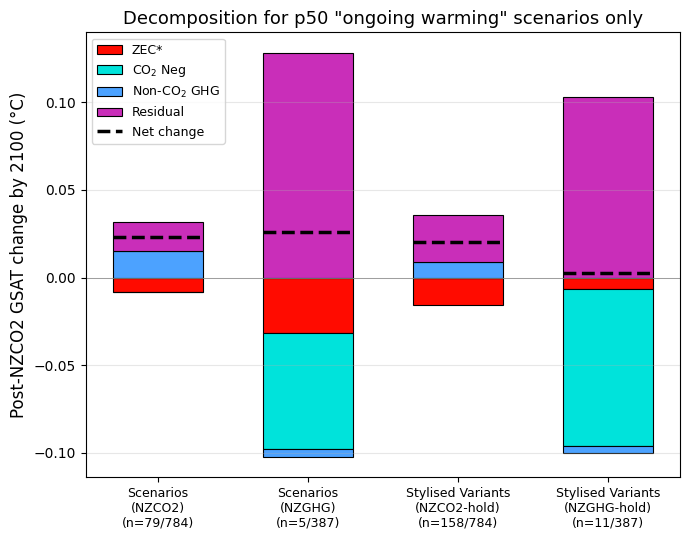

In [10]:
from matplotlib.lines import Line2D

color_delta = {
    'CO2_NZCO2': '#FF0B00',
    'CO2_Negative': '#00E3DB',
    'NonCO2_GHG': '#4CA2FF',
    'Residual': '#C92EB9',
}
component_labels = {
    'CO2_NZCO2': 'ZEC*',
    'CO2_Negative': 'CO$_2$ Neg',
    'NonCO2_GHG': 'Non-CO$_2$ GHG',
    'Residual': 'Residual',
}
group_labels_short = {
    "Scenarios (NZCO2)": "Scenarios\n(NZCO2)",
    "Scenarios (NZGHG)": "Scenarios\n(NZGHG)",
    "Stylised Variants (NZCO2-hold)": "Stylised Variants\n(NZCO2-hold)",
    "Stylised Variants (NZGHG-hold)": "Stylised Variants\n(NZGHG-hold)",
}

x = np.arange(len(GROUPS))

fig, ax = plt.subplots(figsize=(7, 5.5))

pos_bottom = np.zeros(len(GROUPS))
neg_bottom = np.zeros(len(GROUPS))
for comp in DELTA_COMPONENTS:
    values = ongoing_warming_df.loc[GROUPS, comp].values
    bottoms = np.where(values >= 0, pos_bottom, neg_bottom)
    ax.bar(x, values, width=0.6, bottom=bottoms, color=color_delta[comp],
           edgecolor="black", linewidth=0.8, label=component_labels[comp])
    pos_bottom = np.where(values >= 0, pos_bottom + values, pos_bottom)
    neg_bottom = np.where(values < 0, neg_bottom + values, neg_bottom)

net_change = ongoing_warming_df.loc[GROUPS, "net_change"].values
half_width = 0.3
for i, net in enumerate(net_change):
    ax.plot([i - half_width, i + half_width], [net, net],
            color="black", linestyle="--", linewidth=2.5, zorder=5)

# n= counts folded directly into the tick labels (a separate annotation collided
# with the tick labels below the axis).
xtick_labels = [
    f"{group_labels_short[g]}\n(n={ongoing_warming_df.loc[g, 'n']}/{ongoing_warming_df.loc[g, 'n_total']})"
    for g in GROUPS
]
ax.set_xticks(x)
ax.set_xticklabels(xtick_labels, fontsize=9)
ax.set_ylabel("Post-NZCO2 GSAT change by 2100 (°C)", fontsize=12)
ax.set_title("Decomposition for p50 \"ongoing warming\" scenarios only", fontsize=13)
handles, labels = ax.get_legend_handles_labels()
net_change_handle = Line2D([0], [0], color="black", linestyle="--", linewidth=2.5, label="Net change")
ax.legend(handles + [net_change_handle], labels + ["Net change"], fontsize=9, loc="upper left")
ax.grid(alpha=0.3, axis="y")
ax.axhline(y=0, color="gray", linestyle="-", linewidth=0.5)

plt.tight_layout()
plt.savefig(PLOT_FOLDER / "505_p50_ongoing_warming_decomposition.png", dpi=150, bbox_inches="tight")
plt.show()